# Combined Model Chromatin Deconvolution

May 29, 2025

Deep dive into two loci: An early and late replicating region.

## Goals:
1. Convey the need for copy correction clearly.
2. Show how deconvolution improves the signal of cycling chromatin dynamics.

## Loci:
1. ARS220 (oridb 68) - Near *MCM7*
2. ARS1625.5 (oridb 817) - Early replicating and near *CLB2* and *CLB5*

## Notes and ideas
- Use one of these early replicating regions as a baseline and compare a nearby late replicating region, convey the distance to the efficient early replicating region on a chromosome summary plot above to provide context for the reader.
    - Tension: Using origin annotations rather than replication profiles (next section).
    - Figure/diagram ideas may help the replication, copy correction story.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [66]:
from src.Fig2LocusVignette import LocusVignette

fig2 = LocusVignette('output/draft3_run/')


In [67]:
fig2.load_regions()

Loading chromosome reads: 16
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 7999) to (16, 26, 800)
Loading chromosome reads: 16
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 7999) to (15, 26, 800)
Loading copy correction N, Fr, B from output/draft3_run/
Loading chromosome reads: 16
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication r

In [128]:
fig2.define_gene_configurations()
fig2.compute_and_store_regions(analysis_key='efficient_no_copy', include_origin=True)
fig2.compute_and_store_regions(analysis_key='distal_no_copy', include_origin=False)


Stored origin footprint region
Stored regions for 5 genes
Stored regions for 5 genes


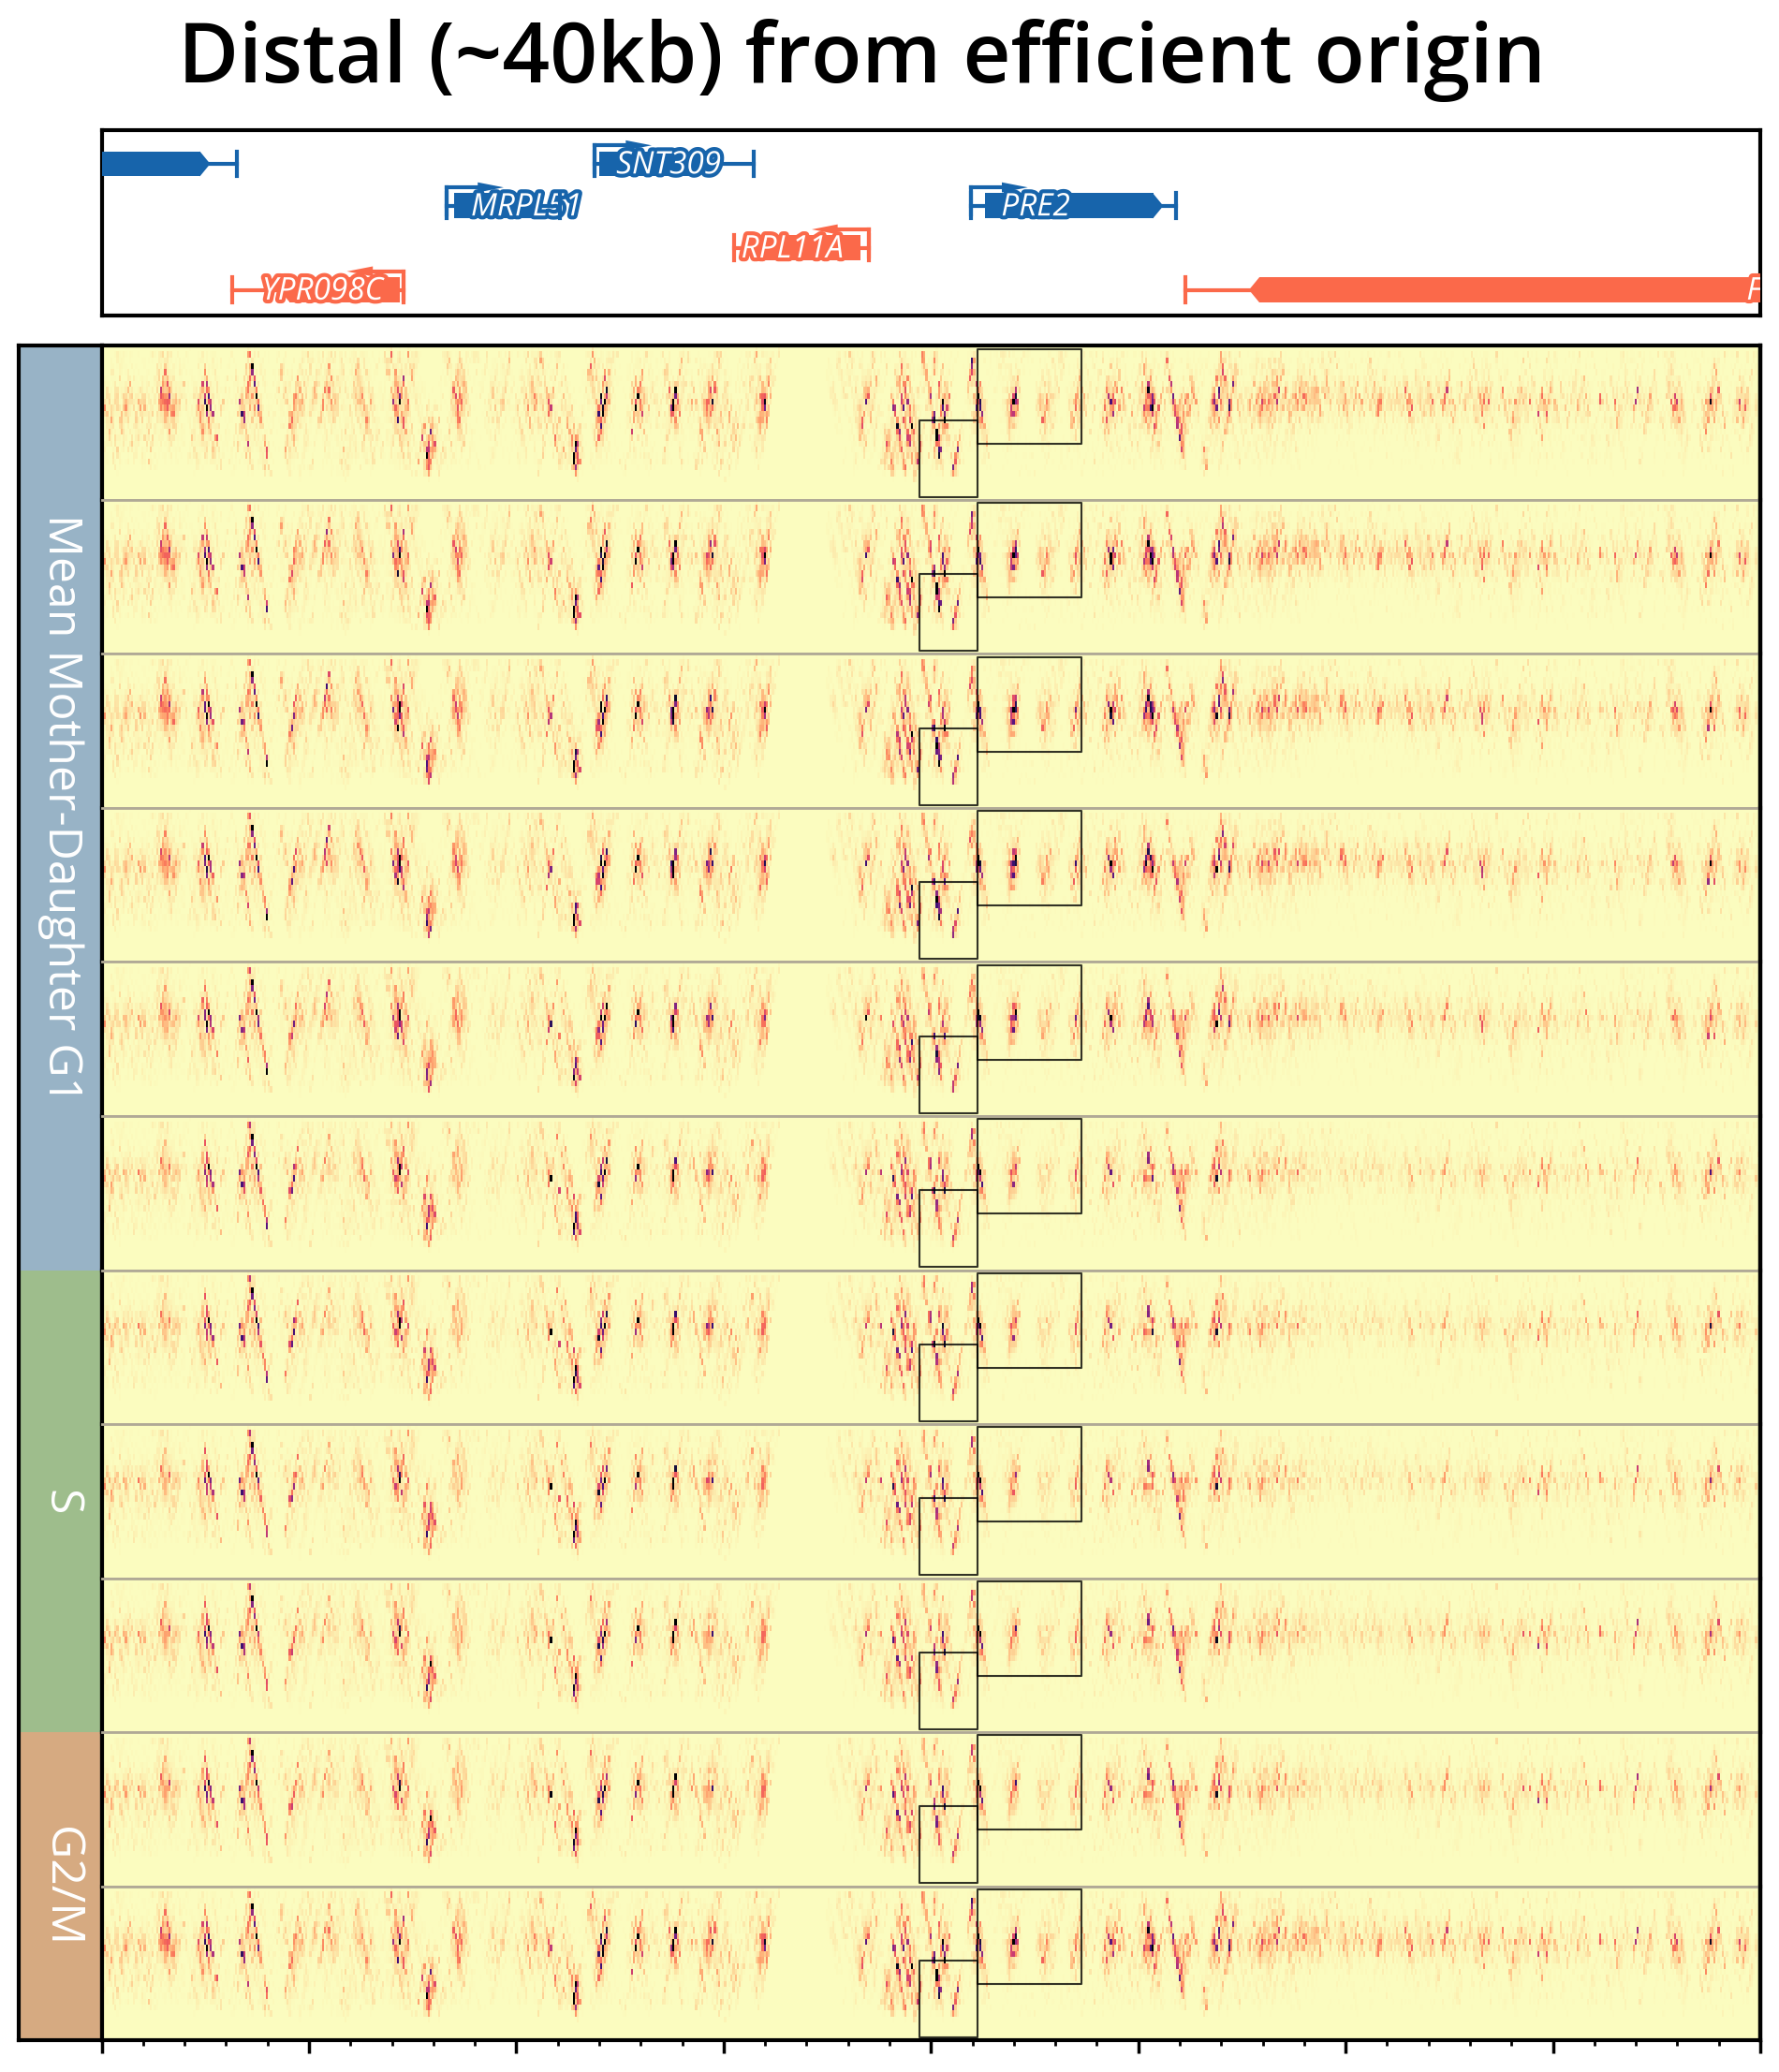

In [129]:
subset_regions = {'PRE2': ['gene_body_bp_tuple', 'promoter_bp_tuple']}
fig2.plot_locus_with_stored_regions(analysis_key='distal_no_copy', 
    regions_to_plot=subset_regions)


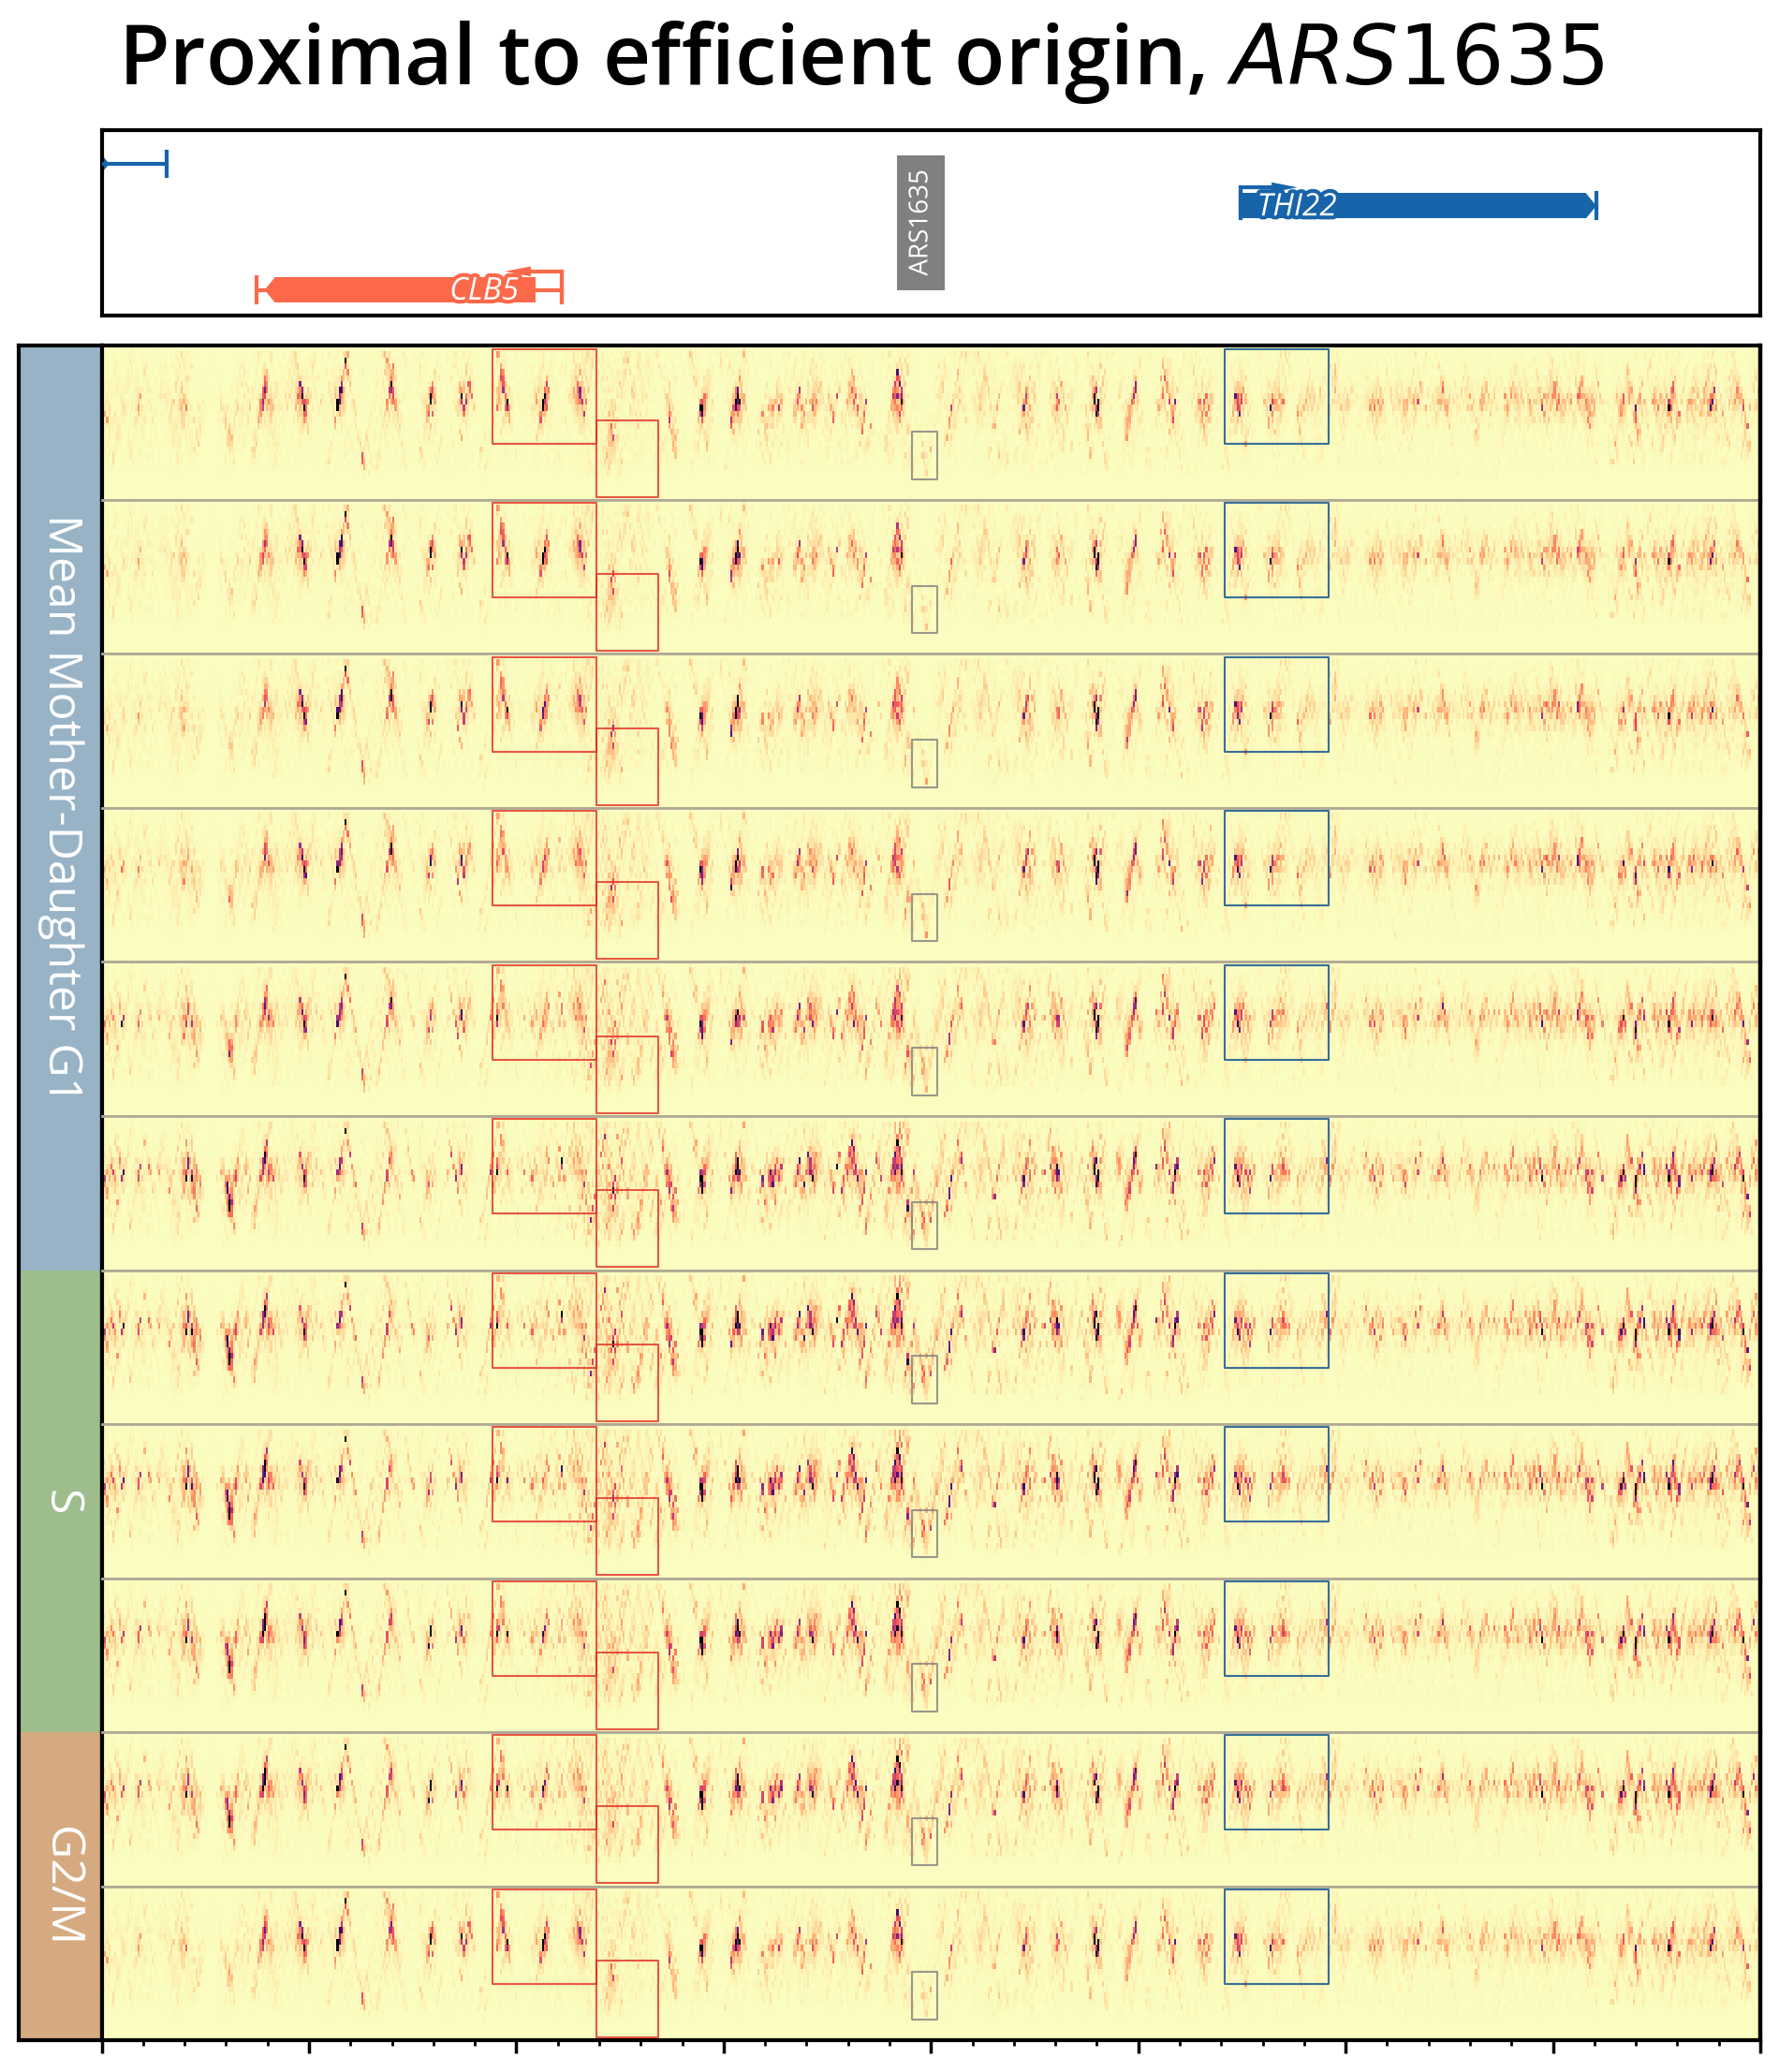

In [112]:
subset_regions = {'CLB5': ['gene_body_bp_tuple', 'promoter_bp_tuple'],
                  'THI22': ['gene_body_bp_tuple']}

fig2.plot_locus_with_stored_regions(analysis_key='efficient_no_copy', 
    regions_to_plot=subset_regions)


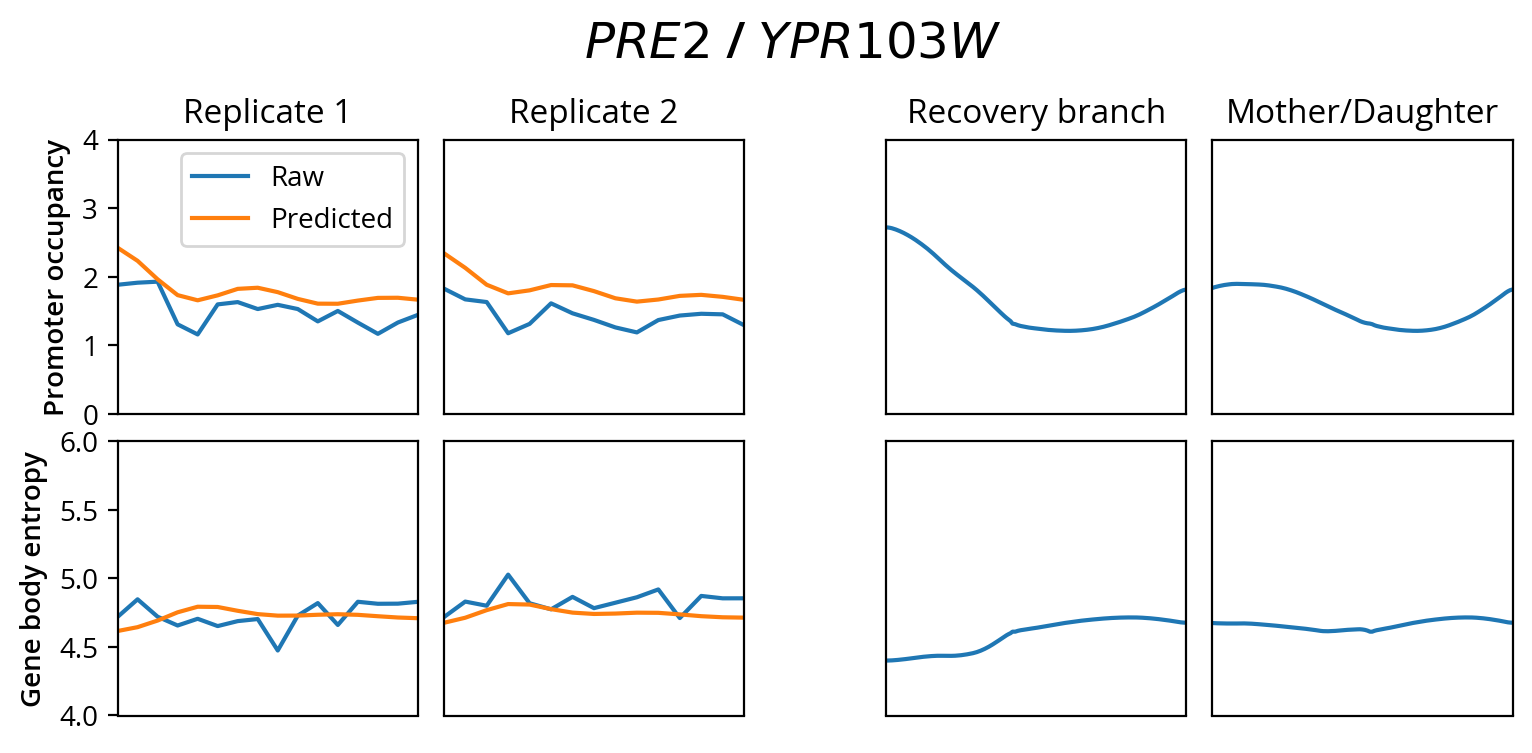

In [166]:

fig = fig2.plot_gene_metrics_grouped('PRE2', analysis_key='distal_no_copy', 
    metrics_to_plot=[
        {'region_type': 'promoter', 'metric_type': 'mean', 
        'label': 'Promoter occupancy',
             'ylim': (0, 4)},        
        {'region_type': 'gene_body', 'metric_type': 'entropy', 
        'label': 'Gene body entropy',
             'ylim': (4, 6)}
    ])


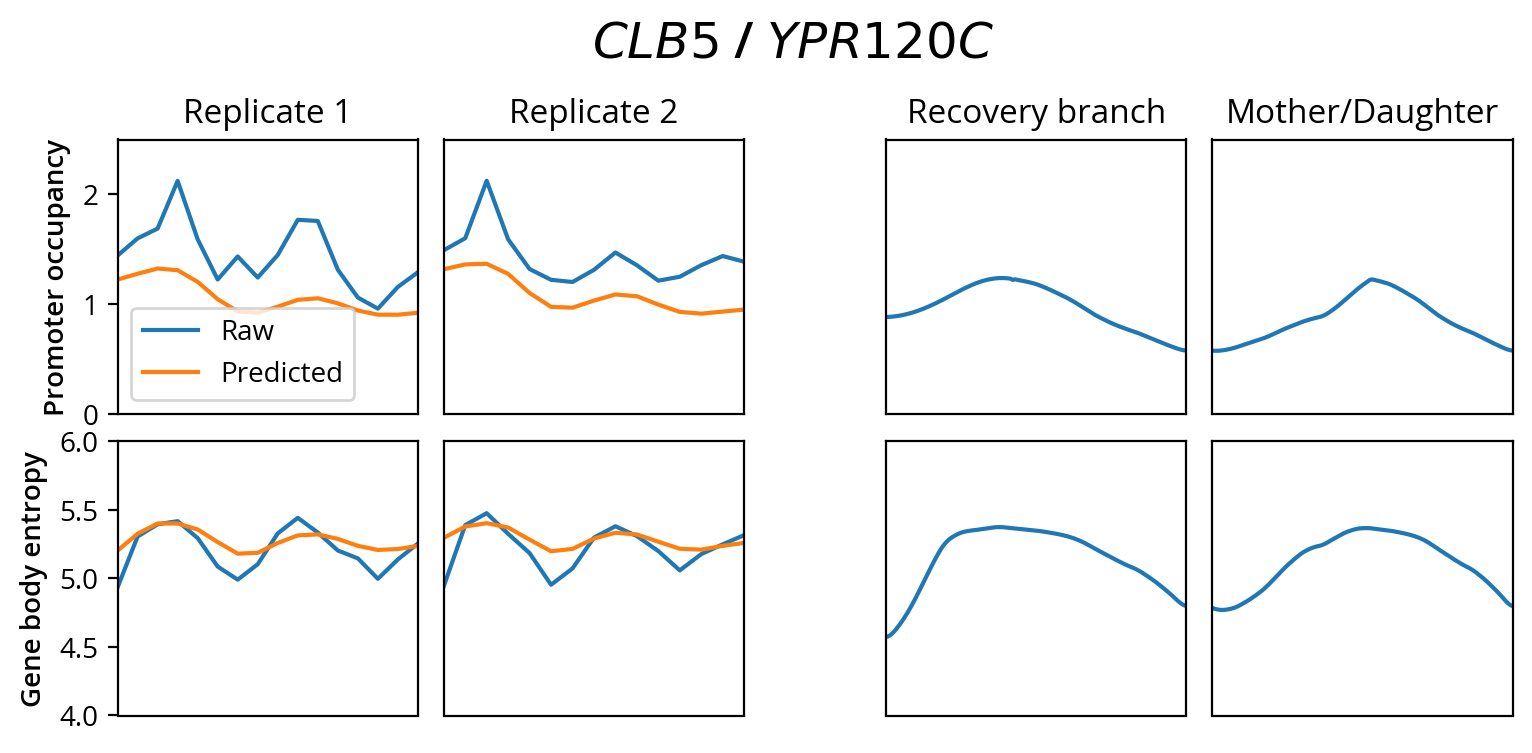

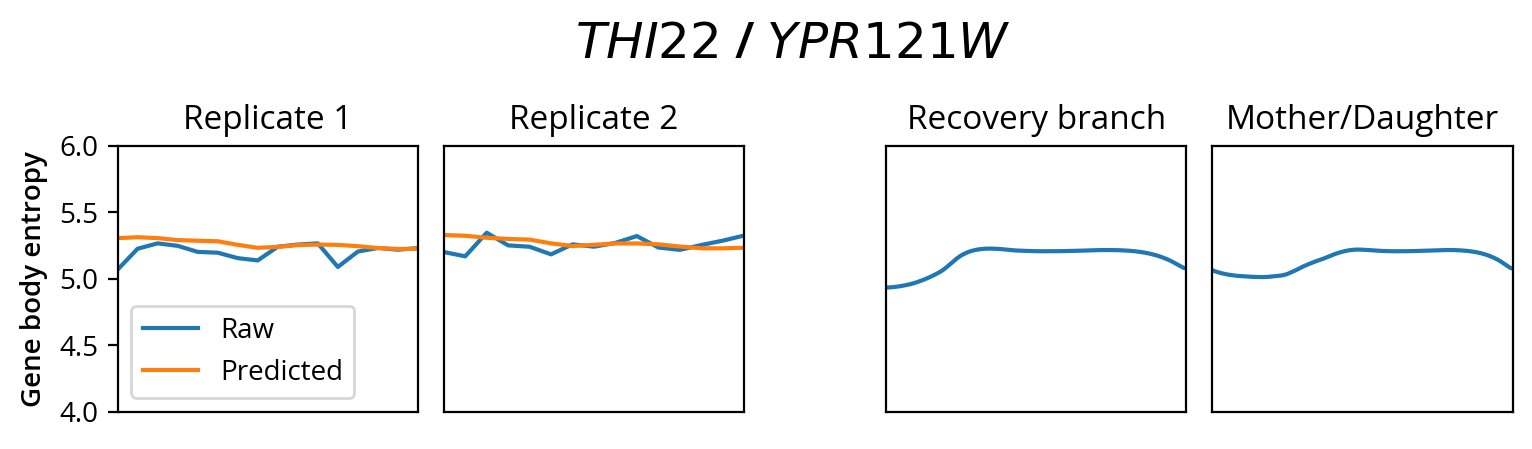

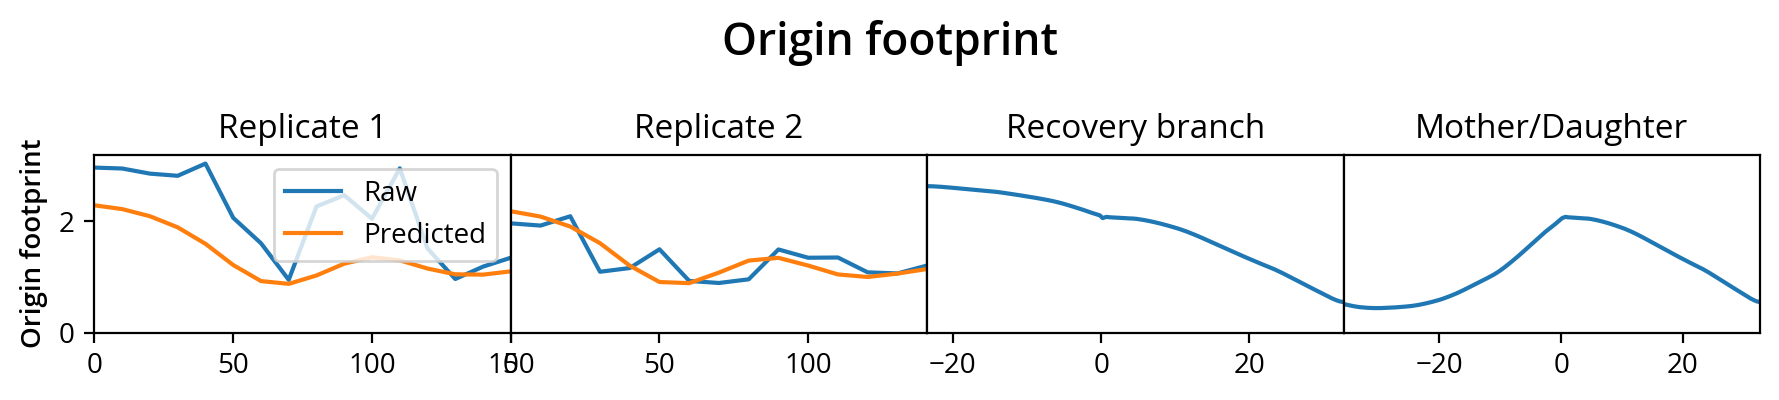

In [165]:

fig = fig2.plot_gene_metrics_grouped('CLB5', analysis_key='efficient_no_copy')
fig = fig2.plot_gene_metrics_grouped('THI22', 
    metrics_to_plot=[{'region_type': 'gene_body', 'metric_type': 'entropy', 
    'label': 'Gene body entropy'}], analysis_key='efficient_no_copy', 
    figsize=(9, 2.25))

fig = fig2.plot_origin_footprint_deconvolution('efficient_no_copy')


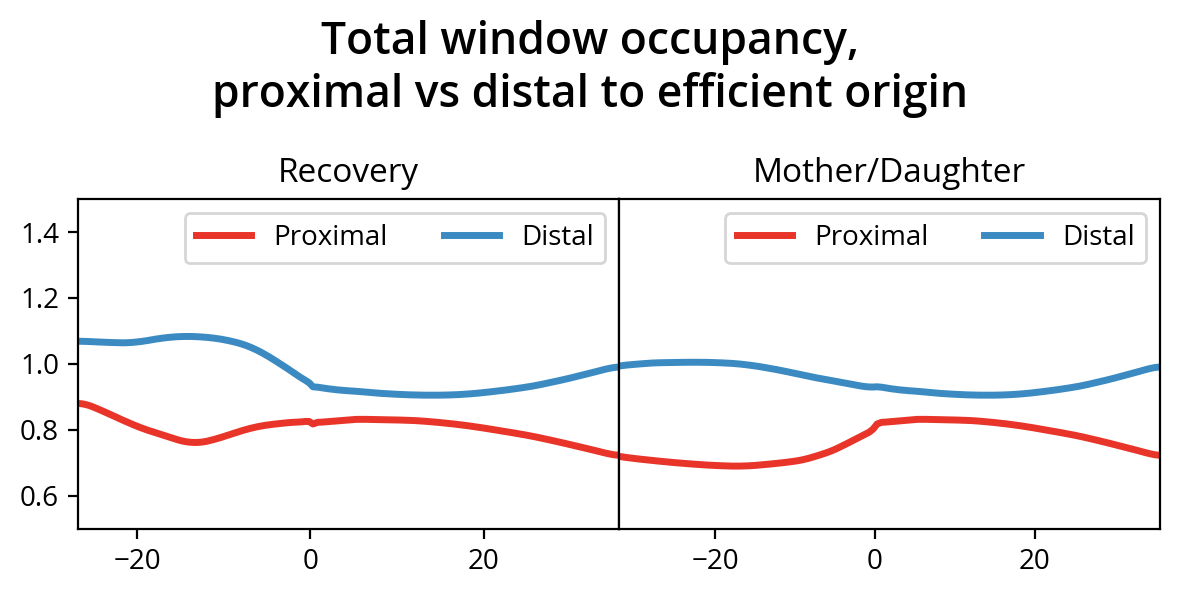

In [143]:
fig2.plot_total_window_comparision(keys=['efficient_with_copy','distal_with_copy'])

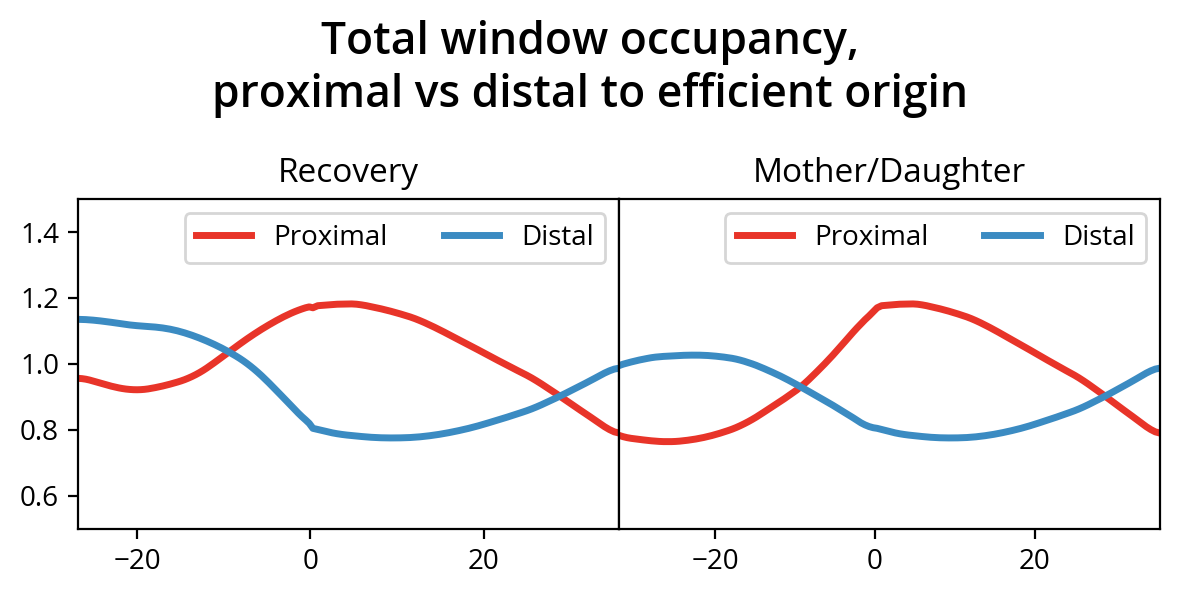

In [144]:
fig2.plot_total_window_comparision()

Text(0.5, 1.0, 'Raw gene expression, replicate 2')

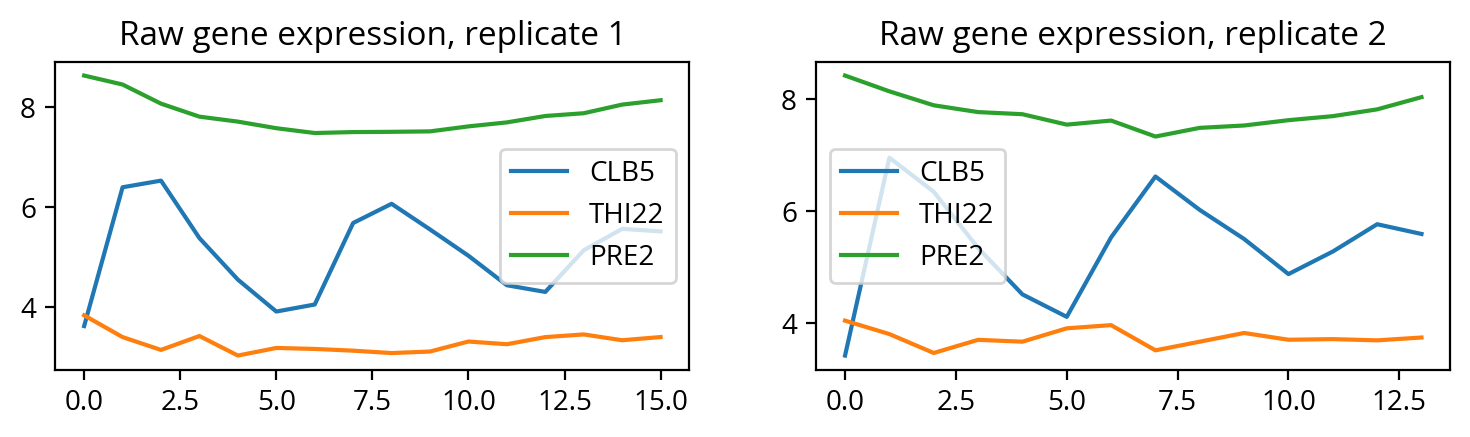

In [141]:
from src.sgd import get_orfnames
gene_names = ['CLB5', 'THI22', 'PRE2']
orfnames = get_orfnames(gene_names)

from src.gene_expression import load_gene_expression_data

raw_expression_rep1 = load_gene_expression_data(1)
raw_expression_rep2 = load_gene_expression_data(2)

plt.figure(figsize=(9, 2))
plt.subplot(1, 2, 1)
plt.plot(raw_expression_rep1.loc[orfnames].values.T, label=gene_names)
plt.legend()
plt.title("Raw gene expression, replicate 1")

plt.subplot(1, 2, 2)
plt.plot(raw_expression_rep2.loc[orfnames].values.T, label=gene_names)
plt.legend()
plt.title("Raw gene expression, replicate 2")
